## A. Data Cleaning

In [2]:
# ----------------------------
# 1. Load and merge datasets
# ----------------------------
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [3]:
### 1.1 Load VR headset data

path = "data/*.csv"
csv_files = glob.glob(path)
df_list = [pd.read_csv(file) for file in csv_files]
vr_df = pd.concat(df_list, ignore_index=True)
vr_df.to_csv("merged_data.csv", index=False)
vr_df = pd.read_csv("merged_data.csv", sep=";")

print("VR data shape:", vr_df.shape)

VR data shape: (250, 7)


In [4]:
### 1.2 Load and clean Survey data

survey_raw = pd.read_excel("Cash Now or Points Later? (Responses).xlsx")

# Helper: find column by keyword
def find_col(keyword, df):
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    return matches[0] if len(matches) > 0 else None

# Find survey columns
col_smart = find_col("smart shopper", survey_raw)
col_util = find_col("practical and functional", survey_raw)
col_hed = find_col("pleasure or enjoyment", survey_raw)
col_equal = find_col("same economic value", survey_raw)
col_understand = find_col("points system worked", survey_raw)
col_pid = find_col("participant ID", survey_raw)
col_age = find_col("age", survey_raw)
col_gender = find_col("gender", survey_raw)
col_loyalty = find_col("collect loyalty points", survey_raw)
col_online = find_col("shop online", survey_raw)
col_retail = find_col("retail stores", survey_raw)
col_programs = find_col("loyalty programs have you used", survey_raw)
col_self = find_col("mostly choose discounts or points", survey_raw)
col_attention = find_col("aquamarine", survey_raw)

# Rename columns
rename_map = {
    col_smart: "smart_shopper",
    col_util: "check_utilitarian",
    col_hed: "check_hedonic",
    col_equal: "check_equal_value",
    col_understand: "check_understanding",
    col_pid: "participant_id",
    col_age: "age",
    col_gender: "gender",
    col_loyalty: "loyalty_freq",
    col_online: "online_freq",
    col_retail: "retail_freq",
    col_programs: "loyalty_programs",
    col_self: "self_report_choice",
    col_attention: "attention_check"
}
rename_map = {k: v for k, v in rename_map.items() if k is not None}

survey_df = survey_raw.rename(columns=rename_map)

# Clean participant_id
survey_df["participant_id"] = pd.to_numeric(survey_df["participant_id"], errors="coerce")

# Attention check
survey_df["attention_check"] = survey_df["attention_check"].astype(str).str.strip().str.lower()
survey_df = survey_df[survey_df["attention_check"] == "aquamarine"].copy()

# Convert Likert items to numeric
likert_cols = ["smart_shopper", "check_utilitarian", "check_hedonic", 
               "check_equal_value", "check_understanding", "loyalty_freq", 
               "online_freq", "retail_freq"]
for col in likert_cols:
    if col in survey_df.columns:
        survey_df[col] = pd.to_numeric(survey_df[col], errors="coerce")

# Clean loyalty programs
survey_df["loyalty_programs_clean"] = survey_df["loyalty_programs"].astype(str).str.lower()
program_keywords = {
    "cashback": "cashback",
    "punch_card": "punch",
    "subscription": "paid subscription",
    "points": "point",
    "tiered": "tiered",
    "other": "other"
}
for new_col, keyword in program_keywords.items():
    survey_df[f"lp_{new_col}"] = survey_df["loyalty_programs_clean"].str.contains(
        keyword, na=False
    ).astype(int)

lp_cols = ["lp_cashback", "lp_punch_card", "lp_subscription", "lp_points", "lp_tiered", "lp_other"]
survey_df["loyalty_program_count"] = survey_df[lp_cols].sum(axis=1)

keep_cols = [
    "participant_id", "smart_shopper", "check_utilitarian", "check_hedonic",
    "check_equal_value", "check_understanding", "age", "gender", "loyalty_freq",
    "online_freq", "retail_freq", "loyalty_programs", "self_report_choice",
    "attention_check", "loyalty_programs_clean", "lp_cashback", "lp_punch_card",
    "lp_subscription", "lp_points", "lp_tiered", "lp_other", "loyalty_program_count"
]
survey_df = survey_df[[c for c in keep_cols if c in survey_df.columns]].copy()

print("Survey data shape after cleaning:", survey_df.shape)

Survey data shape after cleaning: (23, 22)


In [5]:
### 1.3 Merge datasets

merged_df = vr_df.merge(survey_df, on="participant_id", how="inner")
print("Merged dataset shape (after attention check):", merged_df.shape)

# Add product type classification
hedonic = ["Coffee", "Candy Pack", "Nutella", "Juice", "Salt"]
utilitarian = ["Toilet Paper", "Cleanser", "Soap", "Shampoo", "Bleach"]

def classify_product(product):
    if product in hedonic:
        return "hedonic"
    elif product in utilitarian:
        return "utilitarian"
    return "unknown"

merged_df["product_type"] = merged_df["product"].apply(classify_product)

# Standard Error function
def se(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan

print("\nFirst 5 rows of merged dataset:")
merged_df.head()

merged_df.to_csv("merged_data.csv", index=False)

Merged dataset shape (after attention check): (230, 28)

First 5 rows of merged dataset:


In [6]:
# ----------------------------
# 2. Missing data & data quality checks
# ----------------------------
print("Trials per participant:")
trials_per_participant = merged_df.groupby("participant_id").size()
print(trials_per_participant)

print("\nMissing values:")
print(merged_df.isna().sum())

print("\nExtremely fast RTs (<300ms):")
print(merged_df[merged_df["rt_ms"] < 300])

Trials per participant:
participant_id
100    10
101    10
102    10
104    10
105    10
107    10
108    10
109    10
110    10
111    10
112    10
113    10
114    10
115    10
116    10
117    10
118    10
119    10
120    10
121    10
122    10
123    10
124    10
dtype: int64

Missing values:
participant_id            0
experiment_trial          0
trial                     0
product                   0
frame                     0
rt_ms                     0
rating                    0
smart_shopper             0
check_utilitarian         0
check_hedonic             0
check_equal_value         0
check_understanding       0
age                       0
gender                    0
loyalty_freq              0
online_freq               0
retail_freq               0
loyalty_programs          0
self_report_choice        0
attention_check           0
loyalty_programs_clean    0
lp_cashback               0
lp_punch_card             0
lp_subscription           0
lp_points                 0
l

## B. Data Analysis

In [8]:
# ----------------------------
# 3. Descriptive Statistics of VR Headset's results
# ----------------------------

# #### 3.1. Choice frequencies (discount vs points)

# Overall choice tendency (H1)
choice_percent = merged_df["frame"].value_counts(normalize=True) * 100
print("Overall choice percentages:")
print(choice_percent)

# Choice by product type (H3)
choice_by_type = (
    merged_df
    .groupby("product_type")["frame"]
    .value_counts(normalize=True)
    .unstack() * 100
)
print("\nChoice by product type (%):")
print(choice_by_type)

# Choice by product
choice_by_product = (
    merged_df
    .groupby("product")["frame"]
    .value_counts(normalize=True)
    .unstack() * 100
)
print("\nChoice by product (%):")
print(choice_by_product)

Overall choice percentages:
frame
discount    70.0
points      30.0
Name: proportion, dtype: float64

Choice by product type (%):
frame          discount     points
product_type                      
hedonic       69.565217  30.434783
utilitarian   70.434783  29.565217

Choice by product (%):
frame          discount     points
product                           
Bleach        73.913043  26.086957
Candy Pack    78.260870  21.739130
Cleanser      73.913043  26.086957
Coffee        69.565217  30.434783
Juice         73.913043  26.086957
Nutella       60.869565  39.130435
Salt          65.217391  34.782609
Shampoo       73.913043  26.086957
Soap          65.217391  34.782609
Toilet Paper  65.217391  34.782609


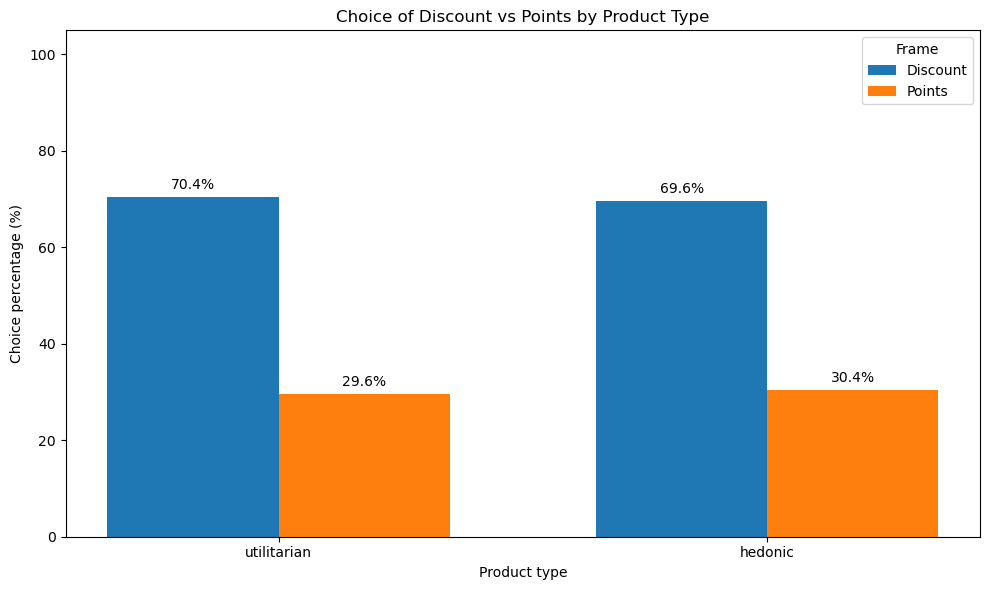

In [9]:
# Plot 1 - Decision choices by Product type
product_types = ["utilitarian", "hedonic"]
frames = ["discount", "points"]

plot_df = choice_by_type.reindex(product_types)[frames]

x = np.arange(len(product_types))
width = 0.35

plt.figure(figsize=(10, 6))

bars_discount = plt.bar(
    x - width/2,
    plot_df["discount"],
    width,
    label="Discount",
    color="tab:blue"
)
bars_points = plt.bar(
    x + width/2,
    plot_df["points"],
    width,
    label="Points",
    color="tab:orange"
)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10
        )
add_labels(bars_discount)
add_labels(bars_points)

plt.xticks(x, product_types)
plt.ylabel("Choice percentage (%)")
plt.xlabel("Product type")
plt.title("Choice of Discount vs Points by Product Type")
plt.ylim(0, 105)
plt.legend(title="Frame")
plt.tight_layout()
plt.show()

In [10]:
# #### 3.2. Ratings (perceived deal value)

# Ratings by frame (H2)
rating_by_frame = (
    merged_df
    .groupby("frame")["rating"]
    .agg(["mean", "std", "count"])
)
print("Ratings by frame:")
print(rating_by_frame)

# Ratings by product type × frame (H2 + H3)
rating_by_product = (
    merged_df
    .groupby(["product_type", "frame"])["rating"]
    .mean()
    .unstack()
)
print("\nRatings by product type × frame:")
print(rating_by_product)

Ratings by frame:
              mean       std  count
frame                              
discount  3.844720  0.978257    161
points    3.724638  0.872523     69

Ratings by product type × frame:
frame         discount    points
product_type                    
hedonic       3.900000  3.657143
utilitarian   3.790123  3.794118


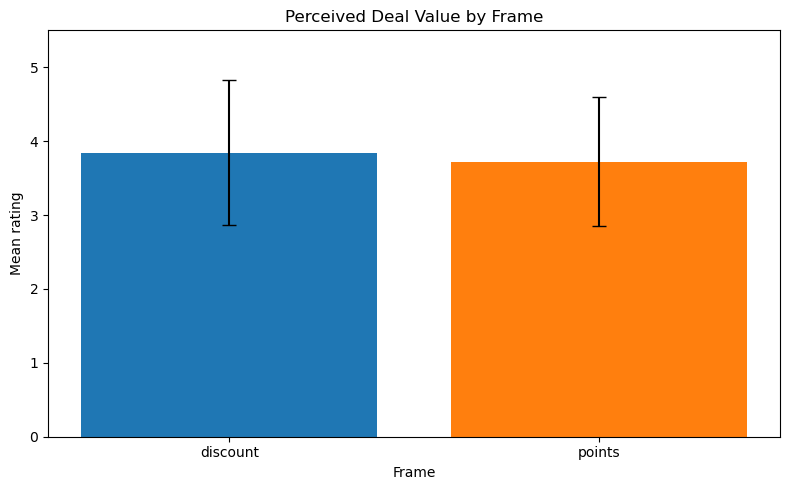

In [11]:
# Plot 2 — Mean rating by frame
rating_by_frame_plot = (
    merged_df
    .groupby("frame")["rating"]
    .agg(["mean", "std"])
    .reset_index()
)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    rating_by_frame_plot["frame"],
    rating_by_frame_plot["mean"],
    yerr=rating_by_frame_plot["std"],
    capsize=5,
    color=["tab:blue", "tab:orange"]
)
plt.xlabel("Frame")
plt.ylabel("Mean rating")
plt.title("Perceived Deal Value by Frame")
plt.ylim(0, 5.5)
plt.tight_layout()
plt.show()

Data for plotting:
  product_type     frame      mean        se   n
0      hedonic  discount  3.900000  0.109081  80
1      hedonic    points  3.657143  0.158474  35
2  utilitarian  discount  3.790123  0.109313  81
3  utilitarian    points  3.794118  0.138617  34


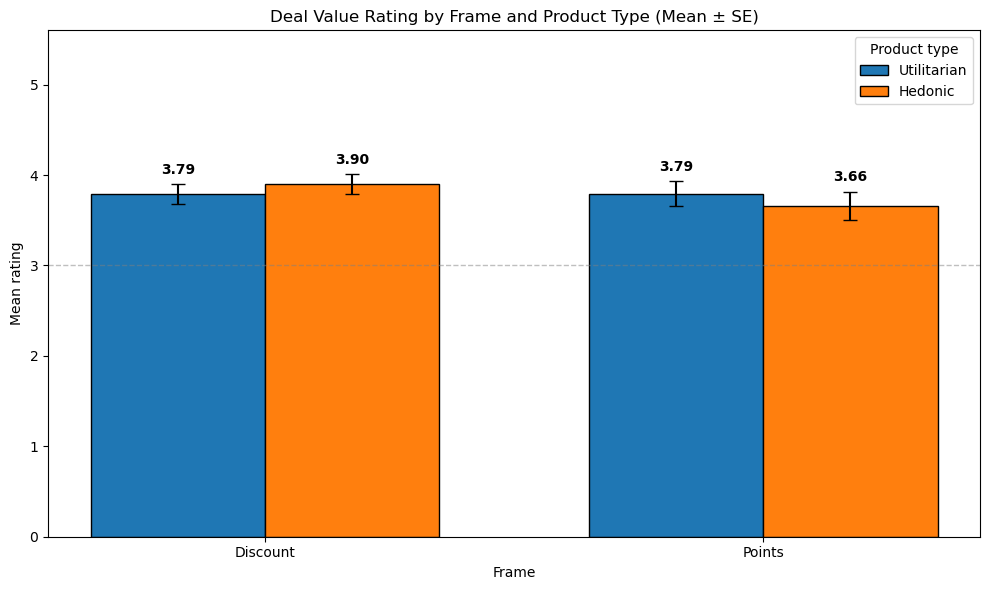


Summary statistics:
frame         discount  points
product_type                  
hedonic           3.90    3.66
utilitarian       3.79    3.79


In [12]:
# Plot 3 — Ratings by product type and frame

# Define product_types and frames 
product_types = ["utilitarian", "hedonic"]
frames = ["discount", "points"]

# Define colors for product types
type_colors = {"utilitarian": "tab:blue", "hedonic": "tab:orange"}

# Create rating_by_type_frame
rating_by_type_frame = (
    merged_df
    .groupby(["product_type", "frame"])["rating"]
    .agg(mean="mean", se=se, n="count")
    .reset_index()
)

# Check data
print("Data for plotting:")
print(rating_by_type_frame)

# Alternative: Group by product type instead of frame
plt.figure(figsize=(10, 6))

# Set up positions
x = np.arange(len(frames))  # [0, 1] for discount, points
width = 0.35

# Create bars for each product type
for i, pt in enumerate(product_types):
    sub = (
        rating_by_type_frame[rating_by_type_frame["product_type"] == pt]
        .set_index("frame")
        .reindex(frames)
    )
    
    means = sub["mean"].fillna(0).values
    errs = sub["se"].fillna(0).values
    
    x_pos = x + (i - 0.5) * width
    
    bars = plt.bar(
        x_pos,
        means,
        width,
        yerr=errs,
        capsize=5,
        color=type_colors[pt],
        edgecolor="black",
        label=pt.title()
    )
    
    # Add value labels
    for j, (xpos, mean, err) in enumerate(zip(x_pos, means, errs)):
        plt.text(
            xpos,
            mean + err + 0.08,
            f"{mean:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

# Add a horizontal line at y=3 (midpoint of scale) for reference
plt.axhline(y=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.xticks(x, [f.capitalize() for f in frames])
plt.xlabel("Frame")
plt.ylabel("Mean rating")
plt.title("Deal Value Rating by Frame and Product Type (Mean ± SE)")
plt.ylim(0, 5.6)
plt.legend(title="Product type")
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary statistics:")
print(rating_by_type_frame.pivot(index='product_type', columns='frame', values='mean').round(2))

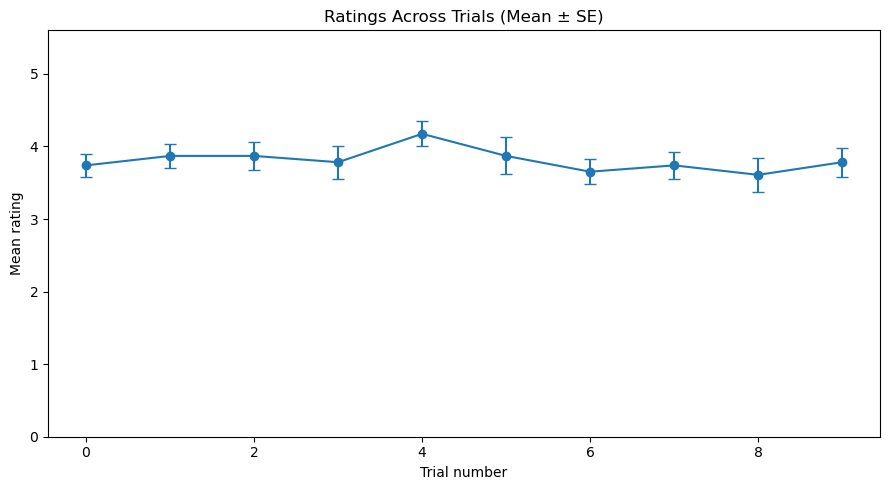

In [13]:
# Plot 4 - Order Effect: Ratings over Trials
rating_by_trial = (
    merged_df
    .groupby("trial")["rating"]
    .agg(mean="mean", se=se)
    .reset_index()
    .sort_values("trial")
)

plt.figure(figsize=(9, 5))
plt.errorbar(
    rating_by_trial["trial"],
    rating_by_trial["mean"],
    yerr=rating_by_trial["se"],
    capsize=4,
    marker="o"
)
plt.xlabel("Trial number")
plt.ylabel("Mean rating")
plt.title("Ratings Across Trials (Mean ± SE)")
plt.ylim(0, 5.6)
plt.tight_layout()
plt.show()

In [14]:
# #### 3.3. Reaction times (RTs)

# Overall reaction time summary
rt_summary_all = merged_df["rt_ms"].agg(
    mean="mean",
    median="median",
    std="std",
    min="min",
    max="max"
)
print("Overall RT summary:")
print(rt_summary_all)

# RT summary by frame
rt_summary_by_frame = (
    merged_df
    .groupby("frame")["rt_ms"]
    .agg(["mean", "median", "std", "min", "max"])
)
print("\nRT by frame:")
print(rt_summary_by_frame)

# RT summary by product type × frame
rt_summary_by_type = (
    merged_df
    .groupby(["product_type", "frame"])["rt_ms"]
    .agg(["mean", "median", "std"])
)
print("\nRT by product type × frame:")
print(rt_summary_by_type)

# RT distribution & outliers
print("RT skewness:", merged_df["rt_ms"].skew())

rt_threshold = merged_df["rt_ms"].quantile(0.95)
slow_trials = merged_df[merged_df["rt_ms"] > rt_threshold]
print("\nSlow trials (>95th percentile):")
print(slow_trials)

Overall RT summary:
mean      13490.047826
median    11076.500000
std       10164.267707
min        2778.000000
max       84852.000000
Name: rt_ms, dtype: float64

RT by frame:
                 mean   median           std   min    max
frame                                                    
discount  13568.31677  11210.0   9785.080941  3667  84852
points    13307.42029  10833.0  11071.683760  2778  78252

RT by product type × frame:
                               mean   median           std
product_type frame                                        
hedonic      discount  12368.500000  11005.5   5453.691861
             points    12844.942857  10655.0   8186.843394
utilitarian  discount  14753.320988  11694.0  12619.956393
             points    13783.500000  10840.0  13530.623418
RT skewness: 3.6427740314518156

Slow trials (>95th percentile):
     participant_id  experiment_trial  trial       product     frame  rt_ms  \
40              123                 0      0      Cleanser  disc

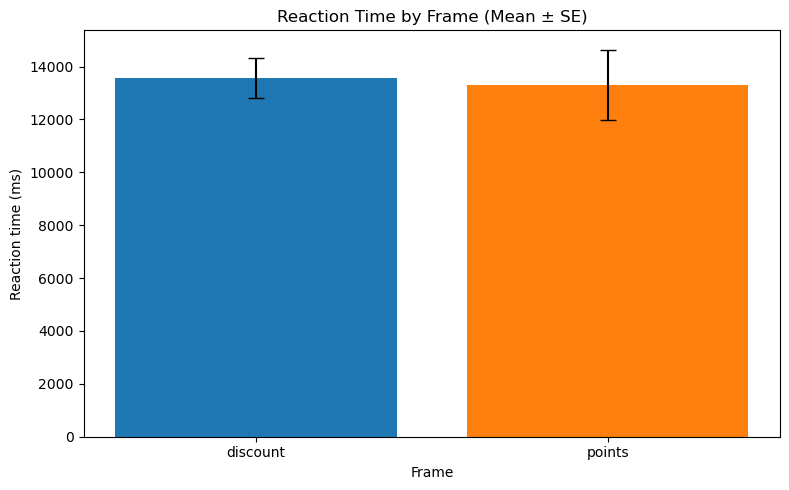

In [15]:
# Plot 5 - Reaction Time by Frame
rt_by_frame = (
    merged_df
    .groupby("frame")["rt_ms"]
    .agg(mean="mean", se=se)
    .reindex(["discount", "points"])
    .reset_index()
)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    rt_by_frame["frame"],
    rt_by_frame["mean"],
    yerr=rt_by_frame["se"],
    capsize=6,
    color=["tab:blue", "tab:orange"]
)
plt.xlabel("Frame")
plt.ylabel("Reaction time (ms)")
plt.title("Reaction Time by Frame (Mean ± SE)")
plt.tight_layout()
plt.show()

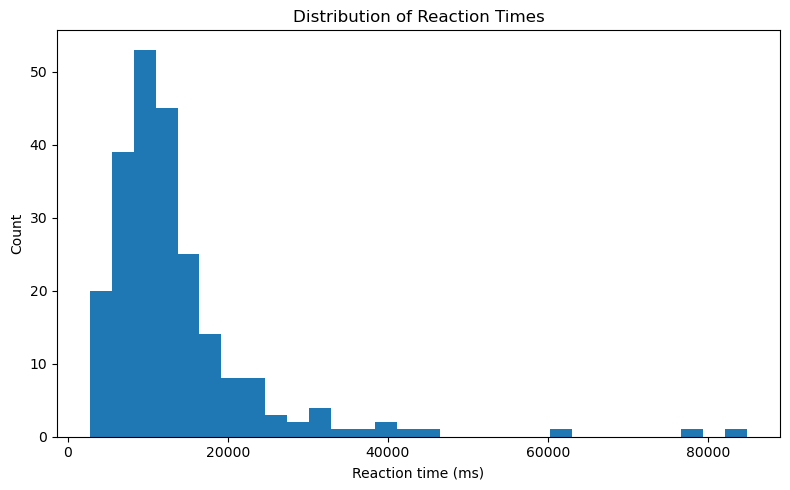

In [16]:
# Plot 6 - Reaction Time Distribution
rt = pd.to_numeric(merged_df["rt_ms"], errors="coerce").dropna()
plt.figure(figsize=(8, 5))
plt.hist(rt, bins=30)
plt.xlabel("Reaction time (ms)")
plt.ylabel("Count")
plt.title("Distribution of Reaction Times")
plt.tight_layout()
plt.show()

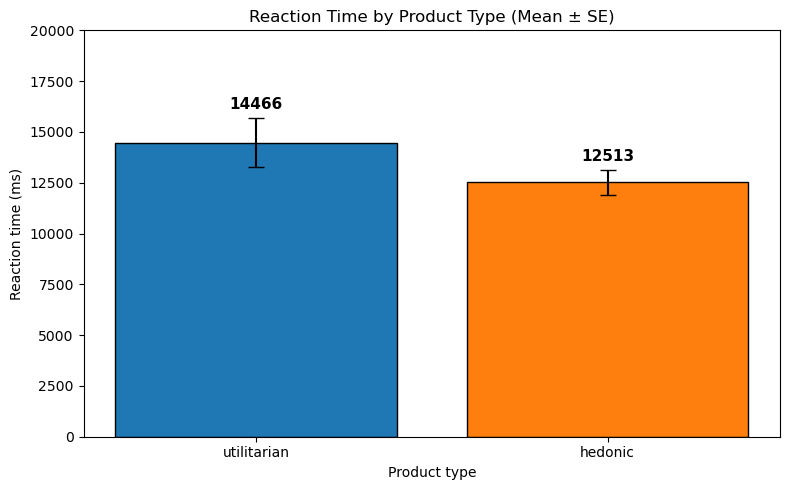

In [17]:
# Plot 7 - Reaction Time by Product Type
rt_by_type = (
    merged_df
    .groupby("product_type")["rt_ms"]
    .agg(mean="mean", se=se, n="count")
    .reset_index()
)

product_order = ["utilitarian", "hedonic"]
rt_by_type = (
    rt_by_type
    .set_index("product_type")
    .reindex(product_order)
    .reset_index()
)
plt.figure(figsize=(8, 5))
colors = ["tab:blue", "tab:orange"]
bars = plt.bar(
    rt_by_type["product_type"],
    rt_by_type["mean"],
    yerr=rt_by_type["se"],
    capsize=6,
    color=colors,
    edgecolor="black"
)

for bar, err in zip(bars, rt_by_type["se"]):
    mean_val = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mean_val + err + 300,
        f"{int(mean_val)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.xlabel("Product type")
plt.ylabel("Reaction time (ms)")
plt.title("Reaction Time by Product Type (Mean ± SE)")
plt.ylim(0, 20000)
plt.tight_layout()
plt.show()

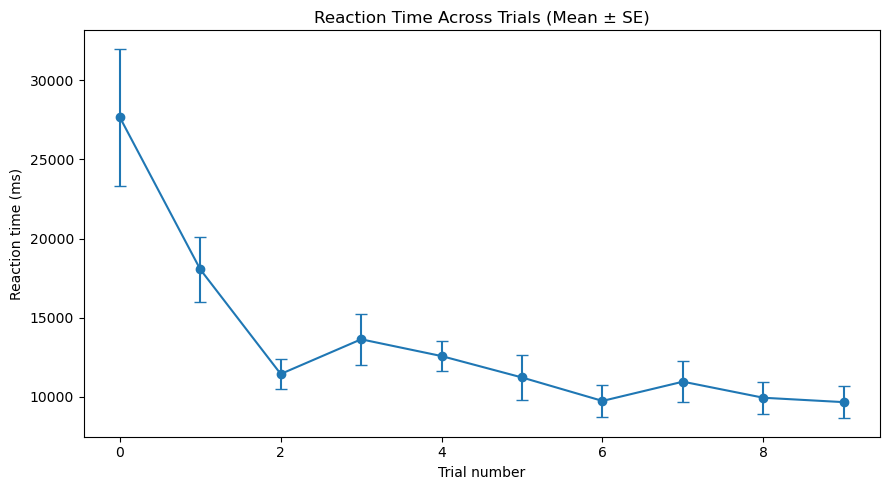

In [18]:
# Plot 8 - Order Effect: RT over Trials
rt_by_trial = (
    merged_df
    .groupby("trial")["rt_ms"]
    .agg(mean="mean", se=se)
    .reset_index()
    .sort_values("trial")
)

plt.figure(figsize=(9, 5))
plt.errorbar(
    rt_by_trial["trial"],
    rt_by_trial["mean"],
    yerr=rt_by_trial["se"],
    capsize=4,
    marker="o"
)
plt.xlabel("Trial number")
plt.ylabel("Reaction time (ms)")
plt.title("Reaction Time Across Trials (Mean ± SE)")
plt.tight_layout()
plt.show()

In [19]:
# #### 3.4. Per-participant summaries

# Participant-level aggregates
participant_summary = (
    merged_df
    .groupby("participant_id")
    .agg(
        mean_rt=("rt_ms", "mean"),
        mean_rating=("rating", "mean"),
        points_share=("frame", lambda x: (x == "points").mean())
    )
    .reset_index()
)
print("Participant summary:")
print(participant_summary)

# Mean RT by frame per participant
participant_rt_by_frame = (
    merged_df
    .groupby(["participant_id", "frame"])["rt_ms"]
    .mean()
    .unstack()
)
print("\nParticipant RT by frame:")
print(participant_rt_by_frame)

# Report variability across participants
print("\nVariability across participants:")
print(participant_summary[["mean_rt", "mean_rating", "points_share"]].agg(["mean", "std"]))

Participant summary:
    participant_id  mean_rt  mean_rating  points_share
0              100  18225.8          2.4           0.1
1              101   9168.4          3.9           0.8
2              102  11835.3          5.0           0.0
3              104  11739.3          4.5           0.0
4              105  14991.6          4.1           0.7
5              107  19196.5          3.4           0.3
6              108  18961.9          3.2           0.2
7              109  17847.8          4.4           0.0
8              110  11717.1          3.0           0.1
9              111  11409.1          3.6           0.3
10             112  12067.4          2.4           0.5
11             113  10410.8          4.7           0.5
12             114   8378.6          4.1           0.8
13             115  10846.7          3.5           0.4
14             116   9913.3          4.1           0.2
15             117  12224.6          4.0           0.1
16             118   9113.0          3.5    

In [20]:
# ----------------------------
# 4. Survey Data Analysis (from merged dataset)
# ----------------------------

# Smart shopper feeling
if "smart_shopper" in merged_df.columns:
    smart_shopper_data = merged_df[["participant_id", "smart_shopper"]].drop_duplicates()
    print("Smart shopper feeling:")
    print(smart_shopper_data["smart_shopper"].describe())
else:
    print("Column 'smart_shopper' not found in merged_df")
    print("Available columns:", merged_df.columns.tolist())

Smart shopper feeling:
count    23.000000
mean      3.565217
std       1.273010
min       1.000000
25%       3.000000
50%       4.000000
75%       5.000000
max       5.000000
Name: smart_shopper, dtype: float64


In [21]:
# Manipulation check questions
check_cols = ["check_utilitarian", "check_hedonic", "check_equal_value", "check_understanding"]
# Only keep existing columns
available_check_cols = [col for col in check_cols if col in merged_df.columns]
if available_check_cols:
    check_df = merged_df[["participant_id"] + available_check_cols].drop_duplicates()
    print("Manipulation checks:")
    print(check_df[available_check_cols].describe())
else:
    print("No manipulation check columns found")

Manipulation checks:
       check_utilitarian  check_hedonic  check_equal_value  \
count          23.000000      23.000000          23.000000   
mean            4.043478       3.173913           3.652174   
std             0.928256       1.230380           1.228772   
min             2.000000       1.000000           1.000000   
25%             4.000000       2.000000           3.000000   
50%             4.000000       3.000000           4.000000   
75%             5.000000       4.000000           5.000000   
max             5.000000       5.000000           5.000000   

       check_understanding  
count            23.000000  
mean              4.347826  
std               0.775107  
min               2.000000  
25%               4.000000  
50%               4.000000  
75%               5.000000  
max               5.000000  


In [22]:
# Percentage rating 4 or higher
if available_check_cols:
    for col in available_check_cols:
        pass_rate = (check_df[col] >= 4).mean() * 100
        print(f"{col}: {pass_rate:.1f}% rated 4 or higher")

# Demographics
demo_cols = ["participant_id", "age", "gender"]
available_demo_cols = [col for col in demo_cols if col in merged_df.columns]
if len(available_demo_cols) >= 2:  # At least participant_id and one other
    demo_df = merged_df[available_demo_cols].drop_duplicates()
    print("\nGender distribution:")
    if "gender" in demo_df.columns:
        print(demo_df["gender"].value_counts(dropna=False))
    print("\nAge distribution:")
    if "age" in demo_df.columns:
        print(demo_df["age"].value_counts().sort_index())
        print("\nAge percentages:")
        print(demo_df["age"].value_counts(normalize=True).sort_index() * 100)

# Self-reported choice
if "self_report_choice" in merged_df.columns:
    self_choice = merged_df[["participant_id", "self_report_choice"]].drop_duplicates()
    print("\nSelf-reported choice:")
    print(self_choice["self_report_choice"].value_counts())
    print("\nSelf-reported choice percentages:")
    print(self_choice["self_report_choice"].value_counts(normalize=True) * 100)

# Loyalty behavior
loyalty_cols = ["participant_id", "loyalty_freq", "online_freq", "retail_freq", "loyalty_program_count"]
available_loyalty_cols = [col for col in loyalty_cols if col in merged_df.columns]

check_utilitarian: 78.3% rated 4 or higher
check_hedonic: 47.8% rated 4 or higher
check_equal_value: 60.9% rated 4 or higher
check_understanding: 91.3% rated 4 or higher

Gender distribution:
gender
Female    15
Male       8
Name: count, dtype: int64

Age distribution:
age
21-25    16
26-30     5
31-35     1
<20       1
Name: count, dtype: int64

Age percentages:
age
21-25    69.565217
26-30    21.739130
31-35     4.347826
<20       4.347826
Name: proportion, dtype: float64

Self-reported choice:
self_report_choice
Discounts    19
Points        4
Name: count, dtype: int64

Self-reported choice percentages:
self_report_choice
Discounts    82.608696
Points       17.391304
Name: proportion, dtype: float64


In [23]:
# Additional descriptive statistics - Shopping Behavior & Loyalty

# Use unique participant data for survey's variables
participant_survey = (
    merged_df[["participant_id", "loyalty_freq", "online_freq", "retail_freq", 
               "loyalty_program_count", "smart_shopper"]]
    .drop_duplicates()
    .dropna()
)

print("=" * 60)
print("DESCRIPTIVE STATISTICS - SHOPPING BEHAVIOR & LOYALTY")
print("=" * 60)

# a. Loyalty Frequency (1-5 scale)
print("\n" + "=" * 40)
print("LOYALTY FREQUENCY (1-5 scale)")
print("=" * 40)
print("Question: How often do you collect loyalty points when shopping?")
print("\nDescriptive statistics:")
loyalty_stats = participant_survey["loyalty_freq"].describe()
print(loyalty_stats)

print("\nFrequency distribution:")
loyalty_dist = participant_survey["loyalty_freq"].value_counts().sort_index()
for val, count in loyalty_dist.items():
    percentage = (count/len(participant_survey))*100
    print(f"  {val}: {count} participants ({percentage:.1f}%)")

# b. Online Shopping Frequency (1-5 scale)
print("\n" + "=" * 40)
print("ONLINE SHOPPING FREQUENCY (1-5 scale)")
print("=" * 40)
print("Question: How frequently do you shop online?")
print("\nDescriptive statistics:")
online_stats = participant_survey["online_freq"].describe()
print(online_stats)

print("\nFrequency distribution:")
online_dist = participant_survey["online_freq"].value_counts().sort_index()
for val, count in online_dist.items():
    percentage = (count/len(participant_survey))*100
    print(f"  {val}: {count} participants ({percentage:.1f}%)")

# c. Retail Shopping Frequency (1-5 scale)
print("\n" + "=" * 40)
print("RETAIL SHOPPING FREQUENCY (1-5 scale)")
print("=" * 40)
print("Question: How frequently do you shop in retail stores?")
print("\nDescriptive statistics:")
retail_stats = participant_survey["retail_freq"].describe()
print(retail_stats)

print("\nFrequency distribution:")
retail_dist = participant_survey["retail_freq"].value_counts().sort_index()
for val, count in retail_dist.items():
    percentage = (count/len(participant_survey))*100
    print(f"  {val}: {count} participants ({percentage:.1f}%)")

# d. Loyalty Program Types
print("\n" + "=" * 40)
print("LOYALTY PROGRAM TYPES")
print("=" * 40)

loyalty_program_cols = ["lp_cashback", "lp_punch_card", "lp_subscription", 
                        "lp_points", "lp_tiered", "lp_other"]
available_lp_cols = [col for col in loyalty_program_cols if col in merged_df.columns]

if available_lp_cols:
    lp_data = merged_df[["participant_id"] + available_lp_cols].drop_duplicates()
    
    program_names = {
        "lp_cashback": "Cashback",
        "lp_punch_card": "Punch Card",
        "lp_subscription": "Subscription",
        "lp_points": "Point-based",
        "lp_tiered": "Tiered",
        "lp_other": "Other"
    }
print("\nTypes of loyalty programs used:")
for col in available_lp_cols:
        count = lp_data[col].sum()
        percentage = (count/len(lp_data))*100
        print(f"  {program_names.get(col, col)}: {int(count)} participants ({percentage:.1f}%)")

# e. Number of Loyalty Programs Used
print("\n" + "=" * 40)
print("NUMBER OF LOYALTY PROGRAMS USED")
print("=" * 40)

if "loyalty_program_count" in participant_survey.columns:
    program_count_stats = participant_survey["loyalty_program_count"].describe()
    print("\nDescriptive statistics:")
    print(program_count_stats)
    
    print("\nDistribution:")
    count_dist = participant_survey["loyalty_program_count"].value_counts().sort_index()
    for val, count in count_dist.items():
        percentage = (count/len(participant_survey))*100
        print(f"  {int(val)} program(s): {count} participants ({percentage:.1f}%)")

# f. Correlation between shopping behaviors
print("\n" + "=" * 40)
print("CORRELATIONS BETWEEN SHOPPING BEHAVIORS")
print("=" * 40)

shopping_cols = ["loyalty_freq", "online_freq", "retail_freq"]
available_shopping_cols = [col for col in shopping_cols if col in participant_survey.columns]

if len(available_shopping_cols) >= 2:
    corr_matrix = participant_survey[available_shopping_cols].corr()
    print("\nCorrelation matrix:")
    print(corr_matrix.round(3))
    
    # Highlight strong correlations
    print("\nKey observations:")
    for i in range(len(available_shopping_cols)):
        for j in range(i+1, len(available_shopping_cols)):
            col1, col2 = available_shopping_cols[i], available_shopping_cols[j]
            corr = corr_matrix.loc[col1, col2]
            strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"  
            print(f"  {col1} vs {col2}: {corr:.3f} ({strength} correlation)")

DESCRIPTIVE STATISTICS - SHOPPING BEHAVIOR & LOYALTY

LOYALTY FREQUENCY (1-5 scale)
Question: How often do you collect loyalty points when shopping?

Descriptive statistics:
count    23.000000
mean      2.956522
std       1.147260
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       5.000000
Name: loyalty_freq, dtype: float64

Frequency distribution:
  1: 1 participants (4.3%)
  2: 10 participants (43.5%)
  3: 3 participants (13.0%)
  4: 7 participants (30.4%)
  5: 2 participants (8.7%)

ONLINE SHOPPING FREQUENCY (1-5 scale)
Question: How frequently do you shop online?

Descriptive statistics:
count    23.000000
mean      3.434783
std       1.079818
min       2.000000
25%       3.000000
50%       3.000000
75%       4.000000
max       5.000000
Name: online_freq, dtype: float64

Frequency distribution:
  2: 5 participants (21.7%)
  3: 8 participants (34.8%)
  4: 5 participants (21.7%)
  5: 5 participants (21.7%)

RETAIL SHOPPING FREQUENCY (1-5 scale)
Ques


VISUALIZATIONS


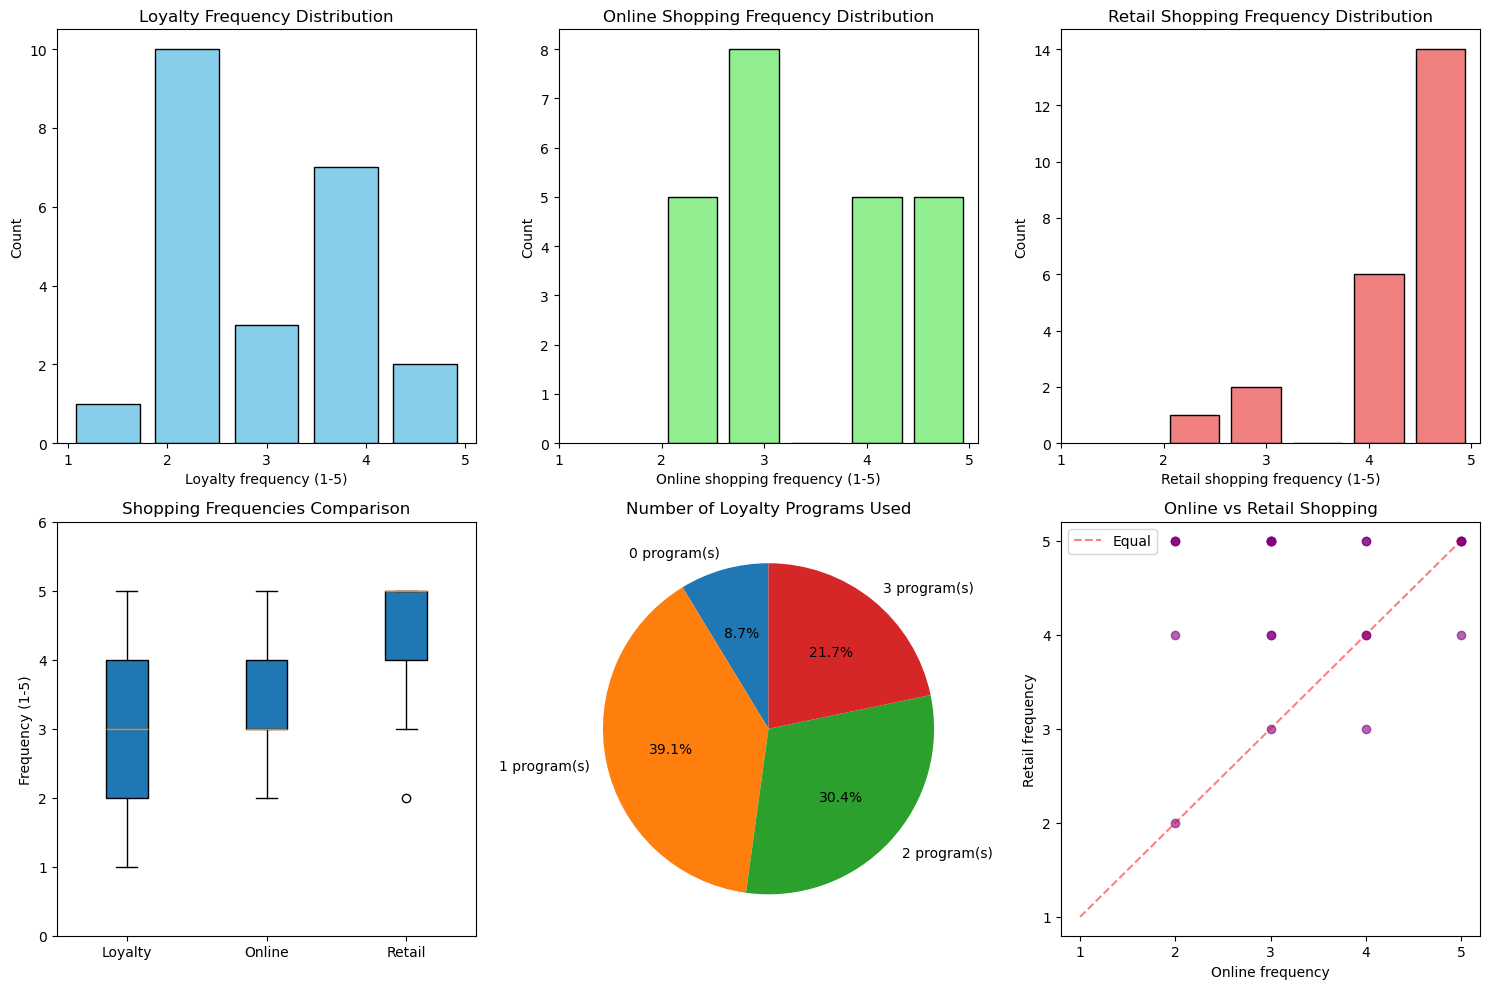

In [24]:
# g. Visualizations
print("\n" + "=" * 40)
print("VISUALIZATIONS")
print("=" * 40)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Histogram for Loyalty Frequency
if "loyalty_freq" in participant_survey.columns:
    axes[0,0].hist(participant_survey["loyalty_freq"], bins=5, edgecolor="black", 
                   color="skyblue", rwidth=0.8)
    axes[0,0].set_xlabel("Loyalty frequency (1-5)")
    axes[0,0].set_ylabel("Count")
    axes[0,0].set_title("Loyalty Frequency Distribution")
    axes[0,0].set_xticks([1, 2, 3, 4, 5])

# Histogram for Online Frequency
if "online_freq" in participant_survey.columns:
    axes[0,1].hist(participant_survey["online_freq"], bins=5, edgecolor="black", 
                   color="lightgreen", rwidth=0.8)
    axes[0,1].set_xlabel("Online shopping frequency (1-5)")
    axes[0,1].set_ylabel("Count")
    axes[0,1].set_title("Online Shopping Frequency Distribution")
    axes[0,1].set_xticks([1, 2, 3, 4, 5])

# Histogram for Retail Frequency
if "retail_freq" in participant_survey.columns:
    axes[0,2].hist(participant_survey["retail_freq"], bins=5, edgecolor="black", 
                   color="lightcoral", rwidth=0.8)
    axes[0,2].set_xlabel("Retail shopping frequency (1-5)")
    axes[0,2].set_ylabel("Count")
    axes[0,2].set_title("Retail Shopping Frequency Distribution")
    axes[0,2].set_xticks([1, 2, 3, 4, 5])

# Boxplots comparison
shopping_data = []
shopping_labels = []
if "loyalty_freq" in participant_survey.columns:
    shopping_data.append(participant_survey["loyalty_freq"])
    shopping_labels.append("Loyalty")
if "online_freq" in participant_survey.columns:
    shopping_data.append(participant_survey["online_freq"])
    shopping_labels.append("Online")
if "retail_freq" in participant_survey.columns:
    shopping_data.append(participant_survey["retail_freq"])
    shopping_labels.append("Retail")

if shopping_data:
    axes[1,0].boxplot(shopping_data, tick_labels=shopping_labels, patch_artist=True)
    axes[1,0].set_ylabel("Frequency (1-5)")
    axes[1,0].set_title("Shopping Frequencies Comparison")
    axes[1,0].set_ylim(0, 6)

# Pie chart - Loyalty program count
if "loyalty_program_count" in participant_survey.columns:
    count_dist = participant_survey["loyalty_program_count"].value_counts().sort_index()
    if not count_dist.empty:
        axes[1,1].pie(count_dist.values, labels=[f"{int(x)} program(s)" for x in count_dist.index], 
                      autopct='%1.1f%%', startangle=90)
        axes[1,1].set_title("Number of Loyalty Programs Used")

# Scatter plot - Online vs Retail
if "online_freq" in participant_survey.columns and "retail_freq" in participant_survey.columns:
    axes[1,2].scatter(participant_survey["online_freq"], participant_survey["retail_freq"], 
                      alpha=0.6, color="purple")
    axes[1,2].set_xlabel("Online frequency")
    axes[1,2].set_ylabel("Retail frequency")
    axes[1,2].set_title("Online vs Retail Shopping")
    axes[1,2].set_xticks([1, 2, 3, 4, 5])
    axes[1,2].set_yticks([1, 2, 3, 4, 5])
    # Add diagonal line
    axes[1,2].plot([1, 5], [1, 5], 'r--', alpha=0.5, label='Equal')
    axes[1,2].legend()

plt.tight_layout()
plt.show()

In [25]:
# h. Summary Table
print("\n" + "=" * 40)
print("SUMMARY TABLE - SHOPPING BEHAVIORS")
print("=" * 40)

summary_table = pd.DataFrame({
    'Metric': ['Loyalty Frequency', 'Online Shopping', 'Retail Shopping', 'Number of Programs'],
    'Mean': [
        f"{participant_survey['loyalty_freq'].mean():.2f}" if 'loyalty_freq' in participant_survey else 'N/A',
        f"{participant_survey['online_freq'].mean():.2f}" if 'online_freq' in participant_survey else 'N/A',
        f"{participant_survey['retail_freq'].mean():.2f}" if 'retail_freq' in participant_survey else 'N/A',
        f"{participant_survey['loyalty_program_count'].mean():.2f}" if 'loyalty_program_count' in participant_survey else 'N/A'
    ],
    'Median': [
        f"{participant_survey['loyalty_freq'].median():.0f}" if 'loyalty_freq' in participant_survey else 'N/A',
        f"{participant_survey['online_freq'].median():.0f}" if 'online_freq' in participant_survey else 'N/A',
        f"{participant_survey['retail_freq'].median():.0f}" if 'retail_freq' in participant_survey else 'N/A',
        f"{participant_survey['loyalty_program_count'].median():.0f}" if 'loyalty_program_count' in participant_survey else 'N/A'
    ],
    'Std': [
        f"{participant_survey['loyalty_freq'].std():.2f}" if 'loyalty_freq' in participant_survey else 'N/A',
        f"{participant_survey['online_freq'].std():.2f}" if 'online_freq' in participant_survey else 'N/A',
        f"{participant_survey['retail_freq'].std():.2f}" if 'retail_freq' in participant_survey else 'N/A',
        f"{participant_survey['loyalty_program_count'].std():.2f}" if 'loyalty_program_count' in participant_survey else 'N/A'
    ],
    'Min': [
        f"{int(participant_survey['loyalty_freq'].min())}" if 'loyalty_freq' in participant_survey else 'N/A',
        f"{int(participant_survey['online_freq'].min())}" if 'online_freq' in participant_survey else 'N/A',
        f"{int(participant_survey['retail_freq'].min())}" if 'retail_freq' in participant_survey else 'N/A',
        f"{int(participant_survey['loyalty_program_count'].min())}" if 'loyalty_program_count' in participant_survey else 'N/A'
    ],
    'Max': [
        f"{int(participant_survey['loyalty_freq'].max())}" if 'loyalty_freq' in participant_survey else 'N/A',
        f"{int(participant_survey['online_freq'].max())}" if 'online_freq' in participant_survey else 'N/A',
        f"{int(participant_survey['retail_freq'].max())}" if 'retail_freq' in participant_survey else 'N/A',
        f"{int(participant_survey['loyalty_program_count'].max())}" if 'loyalty_program_count' in participant_survey else 'N/A'
    ]
})

print(summary_table.to_string(index=False))


SUMMARY TABLE - SHOPPING BEHAVIORS
            Metric Mean Median  Std Min Max
 Loyalty Frequency 2.96      3 1.15   1   5
   Online Shopping 3.43      3 1.08   2   5
   Retail Shopping 4.43      5 0.84   2   5
Number of Programs 1.65      2 0.93   0   3


In [26]:
# Add smart_shopper
if "smart_shopper" in merged_df.columns:
    available_loyalty_cols.append("smart_shopper")

if available_loyalty_cols:
    loyalty_df = merged_df[available_loyalty_cols].drop_duplicates()
    print("\nLoyalty frequency:")
    if "loyalty_freq" in loyalty_df.columns:
        print(loyalty_df["loyalty_freq"].describe())
    print("\nShopping frequency:")
    freq_cols = [col for col in ["online_freq", "retail_freq"] if col in loyalty_df.columns]
    if freq_cols:
        print(loyalty_df[freq_cols].describe())
    print("\nLoyalty program count:")
    if "loyalty_program_count" in loyalty_df.columns:
        print(loyalty_df["loyalty_program_count"].value_counts().sort_index())
else:
    print("No loyalty data columns found")



Loyalty frequency:
count    23.000000
mean      2.956522
std       1.147260
min       1.000000
25%       2.000000
50%       3.000000
75%       4.000000
max       5.000000
Name: loyalty_freq, dtype: float64

Shopping frequency:
       online_freq  retail_freq
count    23.000000    23.000000
mean      3.434783     4.434783
std       1.079818     0.843482
min       2.000000     2.000000
25%       3.000000     4.000000
50%       3.000000     5.000000
75%       4.000000     5.000000
max       5.000000     5.000000

Loyalty program count:
loyalty_program_count
0    2
1    9
2    7
3    5
Name: count, dtype: int64


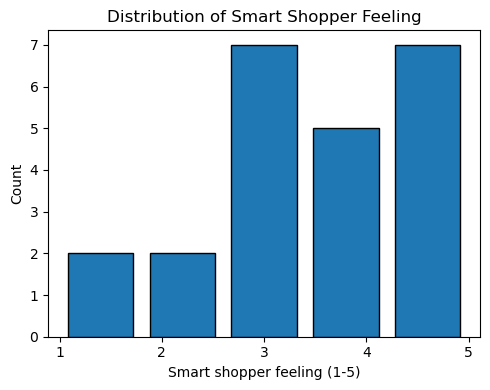

In [27]:
# Plot 9 - Smart shopper distribution 
if "smart_shopper" in loyalty_df.columns:
    plt.figure(figsize=(5, 4))
    plt.hist(loyalty_df["smart_shopper"], bins=5, edgecolor="black", rwidth=0.8)
    plt.xlabel("Smart shopper feeling (1-5)")
    plt.ylabel("Count")
    plt.title("Distribution of Smart Shopper Feeling")
    plt.xticks([1, 2, 3, 4, 5])
    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: 'smart_shopper' column not found")

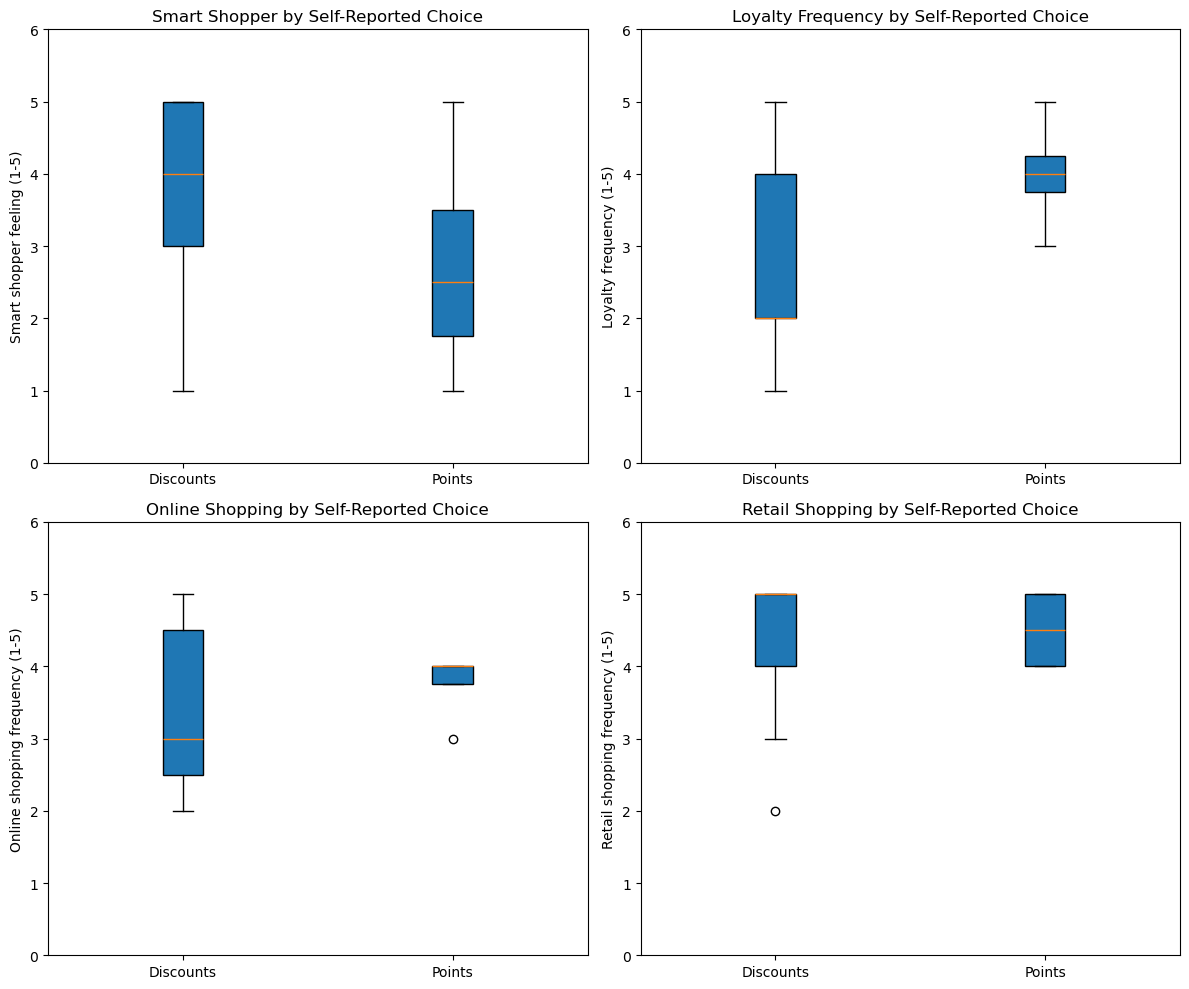

In [28]:
# Plot 10.1 - Boxplots by self-reported choice 
if "self_report_choice" in merged_df.columns and "smart_shopper" in merged_df.columns:
    groups = ["Discounts", "Points"]
    self_choice = merged_df[["participant_id", "self_report_choice"]].drop_duplicates()
    self_choice = self_choice.set_index("participant_id")
    
    # Merge with loyalty data
    plot_df = loyalty_df.merge(self_choice, on="participant_id")
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Smart shopper
    data_smart = [plot_df[plot_df["self_report_choice"] == g]["smart_shopper"].dropna() for g in groups]
    if any(len(d) > 0 for d in data_smart):
        bp1 = axes[0,0].boxplot(data_smart, tick_labels=groups, patch_artist=True)
        axes[0,0].set_ylabel("Smart shopper feeling (1-5)")
        axes[0,0].set_title("Smart Shopper by Self-Reported Choice")
        axes[0,0].set_ylim(0, 6)
    
    # Loyalty frequency
    if "loyalty_freq" in plot_df.columns:
        data_loyalty = [plot_df[plot_df["self_report_choice"] == g]["loyalty_freq"].dropna() for g in groups]
        if any(len(d) > 0 for d in data_loyalty):
            bp2 = axes[0,1].boxplot(data_loyalty, tick_labels=groups, patch_artist=True)
            axes[0,1].set_ylabel("Loyalty frequency (1-5)")
            axes[0,1].set_title("Loyalty Frequency by Self-Reported Choice")
            axes[0,1].set_ylim(0, 6)
    
    # Online frequency
    if "online_freq" in plot_df.columns:
        data_online = [plot_df[plot_df["self_report_choice"] == g]["online_freq"].dropna() for g in groups]
        if any(len(d) > 0 for d in data_online):
            bp3 = axes[1,0].boxplot(data_online, tick_labels=groups, patch_artist=True)
            axes[1,0].set_ylabel("Online shopping frequency (1-5)")
            axes[1,0].set_title("Online Shopping by Self-Reported Choice")
            axes[1,0].set_ylim(0, 6)

     # Retail frequency
    if "retail_freq" in plot_df.columns:
        data_retail = [plot_df[plot_df["self_report_choice"] == g]["retail_freq"].dropna() for g in groups]
        if any(len(d) > 0 for d in data_retail):
            bp4 = axes[1,1].boxplot(data_retail, tick_labels=groups, patch_artist=True)
            axes[1,1].set_ylabel("Retail shopping frequency (1-5)")
            axes[1,1].set_title("Retail Shopping by Self-Reported Choice")
            axes[1,1].set_ylim(0, 6)
    
    plt.tight_layout()
    plt.show()
else:
    print("Cannot create boxplots: missing required columns")



Distribution of actual choice groups:
actual_choice_group
Mostly discounts    17
Mostly points        4
Tie                  2
Name: count, dtype: int64


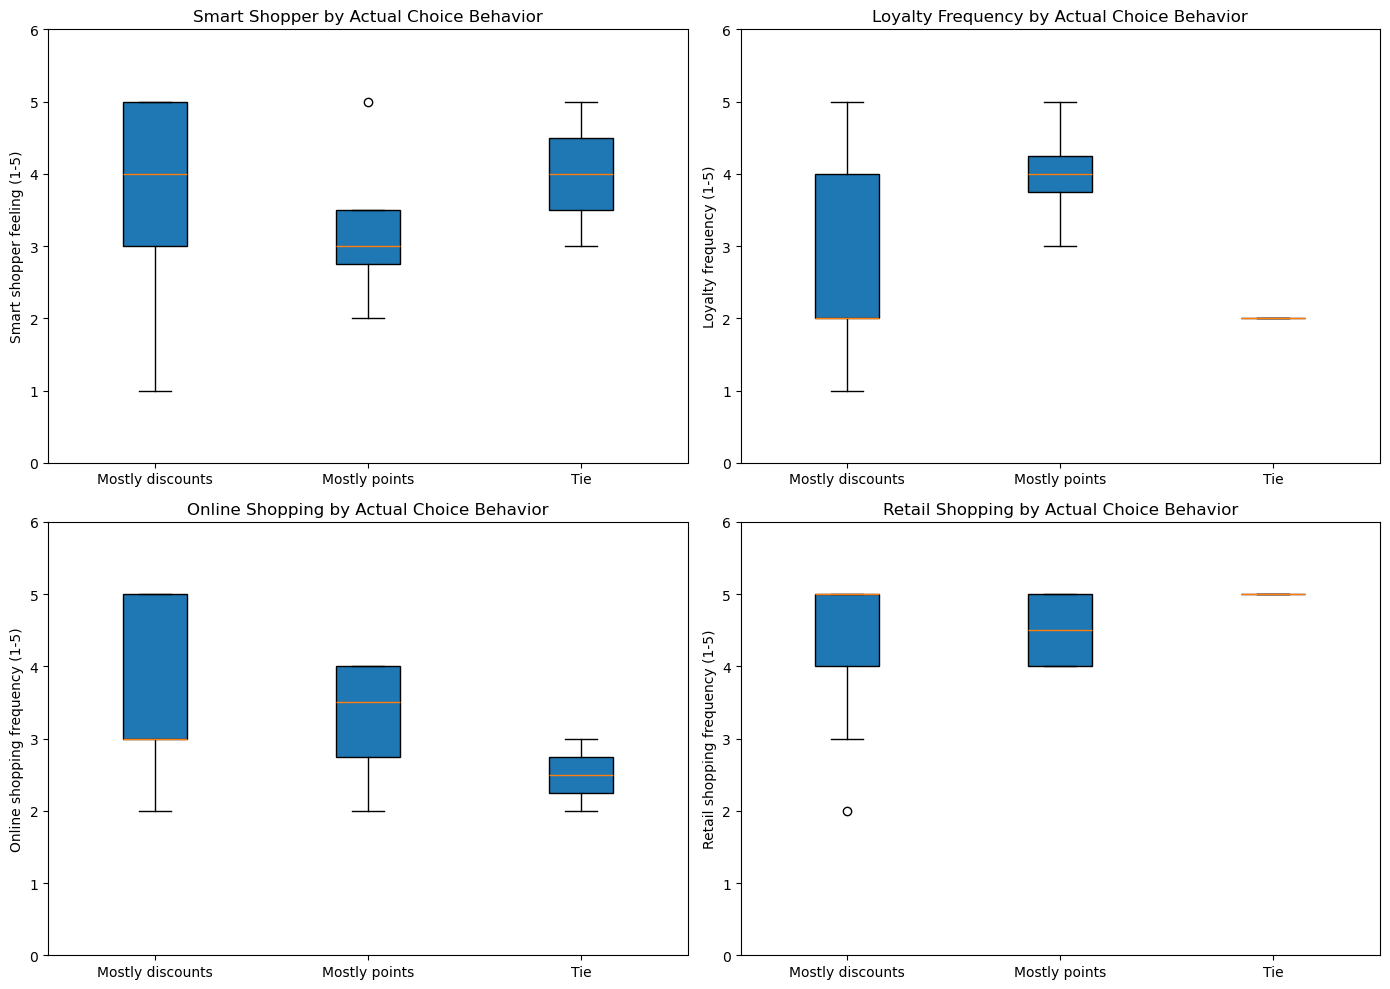


Summary statistics by actual choice group:
                    smart_shopper             loyalty_freq       online_freq  \
                             mean   std count         mean   std        mean   
actual_choice_group                                                            
Mostly discounts             3.59  1.33    17         2.82  1.13        3.59   
Mostly points                3.25  1.26     4         4.00  0.82        3.25   
Tie                          4.00  1.41     2         2.00  0.00        2.50   

                          retail_freq        
                      std        mean   std  
actual_choice_group                          
Mostly discounts     1.12        4.35  0.93  
Mostly points        0.96        4.50  0.58  
Tie                  0.71        5.00  0.00  


In [29]:
# Plot 10.2 - Boxplots by actual behavioral choice
if "smart_shopper" in merged_df.columns:
    # Calculate actual choice behavior for each participant
    participant_behavior = (
        merged_df
        .groupby("participant_id")
        .agg(
            discount_rate=("frame", lambda x: (x == "discount").mean()),
            smart_shopper=("smart_shopper", "first"),
            loyalty_freq=("loyalty_freq", "first"),
            online_freq=("online_freq", "first"),
            retail_freq=("retail_freq", "first"),
            loyalty_program_count=("loyalty_program_count", "first")
        )
        .reset_index()
    )
    
    # Create behavioral choice groups based on actual discount rate
    participant_behavior["actual_choice_group"] = participant_behavior["discount_rate"].apply(
        lambda x: "Mostly discounts" if x > 0.5 else ("Mostly points" if x < 0.5 else "Tie")
    )
    
    print("\nDistribution of actual choice groups:")
    print(participant_behavior["actual_choice_group"].value_counts())
    
    groups = ["Mostly discounts", "Mostly points", "Tie"]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Smart shopper by actual choice
    data_smart = [participant_behavior[participant_behavior["actual_choice_group"] == g]["smart_shopper"].dropna() 
                  for g in groups if g in participant_behavior["actual_choice_group"].values]
    
    if any(len(d) > 0 for d in data_smart):
        bp1 = axes[0,0].boxplot(data_smart, tick_labels=[g for g in groups if g in participant_behavior["actual_choice_group"].values], 
                                patch_artist=True)
        axes[0,0].set_ylabel("Smart shopper feeling (1-5)")
        axes[0,0].set_title("Smart Shopper by Actual Choice Behavior")
        axes[0,0].set_ylim(0, 6)
    
    # Loyalty frequency by actual choice
    data_loyalty = [participant_behavior[participant_behavior["actual_choice_group"] == g]["loyalty_freq"].dropna() 
                    for g in groups if g in participant_behavior["actual_choice_group"].values]
    
    if any(len(d) > 0 for d in data_loyalty):
        bp2 = axes[0,1].boxplot(data_loyalty, tick_labels=[g for g in groups if g in participant_behavior["actual_choice_group"].values],
                                patch_artist=True)
        axes[0,1].set_ylabel("Loyalty frequency (1-5)")
        axes[0,1].set_title("Loyalty Frequency by Actual Choice Behavior")
        axes[0,1].set_ylim(0, 6)
    
    # Online frequency by actual choice
    data_online = [participant_behavior[participant_behavior["actual_choice_group"] == g]["online_freq"].dropna() 
                   for g in groups if g in participant_behavior["actual_choice_group"].values]
    
    if any(len(d) > 0 for d in data_online):
        bp3 = axes[1,0].boxplot(data_online, tick_labels=[g for g in groups if g in participant_behavior["actual_choice_group"].values],
                                patch_artist=True)
        axes[1,0].set_ylabel("Online shopping frequency (1-5)")
        axes[1,0].set_title("Online Shopping by Actual Choice Behavior")
        axes[1,0].set_ylim(0, 6)
    
    # Retail frequency by actual choice
    data_retail = [participant_behavior[participant_behavior["actual_choice_group"] == g]["retail_freq"].dropna() 
                   for g in groups if g in participant_behavior["actual_choice_group"].values]
    
    if any(len(d) > 0 for d in data_retail):
        bp4 = axes[1,1].boxplot(data_retail, tick_labels=[g for g in groups if g in participant_behavior["actual_choice_group"].values],
                                patch_artist=True)
        axes[1,1].set_ylabel("Retail shopping frequency (1-5)")
        axes[1,1].set_title("Retail Shopping by Actual Choice Behavior")
        axes[1,1].set_ylim(0, 6)
    
    # Add colors to boxplots
    for ax in axes.flat:
        for bp in ax.findobj(match=lambda x: hasattr(x, 'get_children') and any(isinstance(child, dict) for child in x.get_children())):
            if hasattr(bp, 'findobj'):
                for patch in bp.findobj(match=lambda x: hasattr(x, 'set_facecolor')):
                    if hasattr(patch, 'set_facecolor'):
                        patch.set_facecolor('lightblue')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary statistics by actual choice group:")
    summary_stats = participant_behavior.groupby("actual_choice_group").agg({
        "smart_shopper": ["mean", "std", "count"],
        "loyalty_freq": ["mean", "std"],
        "online_freq": ["mean", "std"],
        "retail_freq": ["mean", "std"]
    }).round(2)
    print(summary_stats)
    
else:
    print("Cannot create boxplots: 'smart_shopper' column not found")


Self-report accuracy:
Aligned with actual behavior: 82.6%


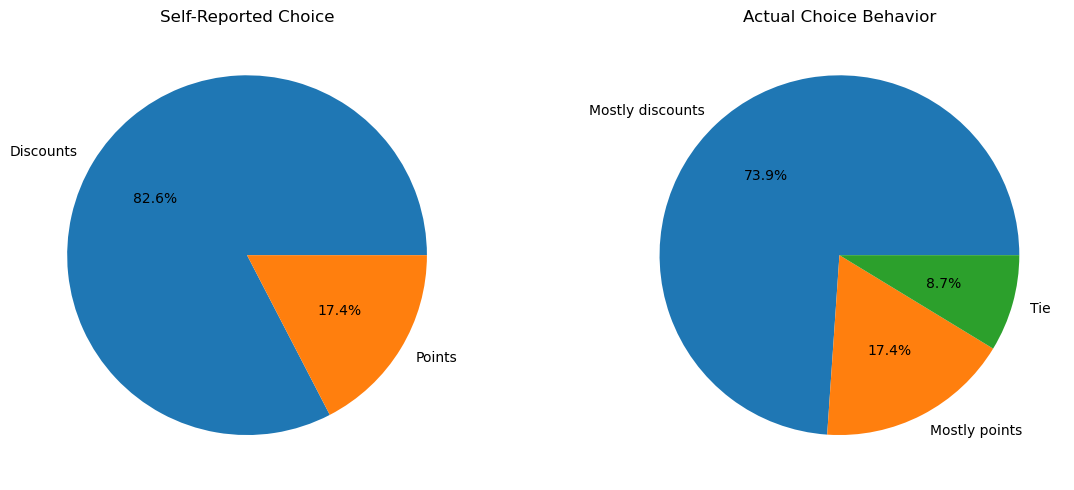

In [30]:
# Plot 11 - Compare self-reported vs actual choice
if "self_report_choice" in merged_df.columns:
    self_choice = merged_df[["participant_id", "self_report_choice"]].drop_duplicates()
    self_choice = self_choice.set_index("participant_id")
    
    # Merge with participant behavior
    comparison_df = participant_behavior.merge(self_choice, on="participant_id")
    
    # Create confusion matrix style comparison
    comparison_df["self_report_aligned"] = comparison_df.apply(
        lambda row: (
            (row["self_report_choice"] == "Discounts" and row["discount_rate"] > 0.5) or
            (row["self_report_choice"] == "Points" and row["discount_rate"] < 0.5)
        ), axis=1
    )
    
    print("\nSelf-report accuracy:")
    print(f"Aligned with actual behavior: {comparison_df['self_report_aligned'].mean()*100:.1f}%")
    
    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Self-reported choice distribution
    self_counts = comparison_df["self_report_choice"].value_counts()
    axes[0].pie(self_counts.values, labels=self_counts.index, autopct='%1.1f%%')
    axes[0].set_title("Self-Reported Choice")
    
    # Actual choice distribution
    actual_counts = comparison_df["actual_choice_group"].value_counts()
    axes[1].pie(actual_counts.values, labels=actual_counts.index, autopct='%1.1f%%')
    axes[1].set_title("Actual Choice Behavior")
    
    plt.tight_layout()
    plt.show()

In [31]:
# ----------------------------
# 5. Hypothesis Testing
# ----------------------------

# H1: Direct discount increases immediate selection rate
h1_result = merged_df["frame"].value_counts(normalize=True) * 100
print("H1 - Choice percentages:")
print(h1_result)

H1 - Choice percentages:
frame
discount    70.0
points      30.0
Name: proportion, dtype: float64


In [32]:
# H2a: Perceived deal value by frame (VR ratings)
h2a_result = merged_df.groupby("frame")["rating"].agg(["mean", "std", "count"])
print("\nH2a - Ratings by frame:")
print(h2a_result)


H2a - Ratings by frame:
              mean       std  count
frame                              
discount  3.844720  0.978257    161
points    3.724638  0.872523     69


In [33]:
# H2b: Smart shopper feeling by actual behavior
participant_behavior = (
    merged_df
    .groupby("participant_id")
    .agg(
        discount_rate=("frame", lambda x: (x == "discount").mean()),
        smart_shopper=("smart_shopper", "first")
    )
    .reset_index()
)
participant_behavior["actual_choice_group"] = participant_behavior["discount_rate"].apply(
    lambda x: "Mostly discounts" if x > 0.5 else ("Mostly points" if x < 0.5 else "Tie")
)

h2b_result = (
    participant_behavior
    .groupby("actual_choice_group")["smart_shopper"]
    .agg(mean="mean", sd="std", median="median", n="count")
    .round(2)
)
print("\nH2b - Smart shopper by actual choice behavior:")
print(h2b_result)


H2b - Smart shopper by actual choice behavior:
                     mean    sd  median   n
actual_choice_group                        
Mostly discounts     3.59  1.33     4.0  17
Mostly points        3.25  1.26     3.0   4
Tie                  4.00  1.41     4.0   2


In [34]:
# H3: Effect differs by product type
h3_result = merged_df.groupby(["product_type", "frame"]).size().groupby(level=0).apply(
    lambda x: x / x.sum() * 100
)
print("H3 - Choice percentages by product type:")
print(h3_result)

H3 - Choice percentages by product type:
product_type  product_type  frame   
hedonic       hedonic       discount    69.565217
                            points      30.434783
utilitarian   utilitarian   discount    70.434783
                            points      29.565217
dtype: float64


In [35]:
# H3 - Ratings by product type and frame
h3_rating = (
    merged_df
    .groupby(["product_type", "frame"])["rating"]
    .agg(["mean", "std"])
)
print("\nH3 - Ratings by product type and frame:")
print(h3_rating)


H3 - Ratings by product type and frame:
                           mean       std
product_type frame                       
hedonic      discount  3.900000  0.975653
             points    3.657143  0.937546
utilitarian  discount  3.790123  0.983820
             points    3.794118  0.808268
